In [1]:
import json

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import v2
import torch.nn as nn

import time
from pathlib import Path

In [4]:
def warm_image_cache(directory):
    directory = Path(directory)
    files = list(directory.rglob("*"))
    files = [p for p in files if p.is_file()]

    total_bytes = sum(p.stat().st_size for p in files)

    print(
        f"Warming cache for {len(files):,} files "
        f"({total_bytes / 1024**3:.2f} GiB)..."
    )

    start = time.perf_counter()

    for i, path in enumerate(files, 1):
        with open(path, "rb") as f:
            while f.read(1024 * 1024):
                pass

        if i % 2000 == 0:
            print(f"{i:,}/{len(files):,} files")

    elapsed = time.perf_counter() - start
    print(f"Cache warm-up completed in {elapsed:.1f}s")

image_dir = 'cassava-leaf-disease-classification/train_images'

In [60]:
path_to_labels = 'cassava-leaf-disease-classification/train.csv'

df = pd.read_csv(path_to_labels) # Read the labels

# Forming 80/10/10 train, validate, test splits

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Ensuring batches are disjoint from one another and that all batches add up to 100%

assert len(train_df) + len(val_df) + len(test_df) == len(df)

assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

class CassavaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, return_path=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image_id"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        if self.return_path:
            return image, label, image_path

        return image, label

# Setting up transformation initial test

train_transform = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.8, 1.0)), # Cropping random portion of the input and resizing it. Scale gives lower and upper bound for the crop area
    v2.RandomHorizontalFlip(), # 50% probability that an image is horizontally flipped
    v2.RandomRotation(degrees=15), # Rotates every image by a random degree from [-15, +15]
    v2.ColorJitter( # Randomly changes the brightnes, contrast, saturation of an image
        brightness=0.1, # Brightness factor is jittered uniformly between [max(0, 1-[0.1]), 1 + [0.1]]
        contrast=0.1, # Contrast factor is jittered uniformly between [max(0, 1-[0.1], (1 + [0.1])]
        saturation=0.1, # Saturation factor is jittered uniformly between [max(0, 1-[0.1]), (1+ [0.1])]
    ),
    v2.ToImage(), # Make image a tensor
    v2.ToDtype(torch.float32, scale=True), # Converts image to have datatype float32. We use float32 rather than uint8 since the network needs floating point numbers to correctly operate. Scale move the image from [0, 255] (default uint8 for JPEG) -> [0, 1]
    v2.Normalize(
        mean=[0.485, 0.456, 0.406], # Mean & Std come directly from the ResNet-18 default models
        std=[0.229, 0.224, 0.225]
    )
])

# Setting up validation transformation

val_transform = v2.Compose([
    v2.Resize(256), # Rescaling to (256 * height/width, 256)
    v2.CenterCrop(224), # Crops the image to size (224x224)
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = v2.Compose([
    v2.Resize(256), # Rescaling to (256 * height/width, 256)
    v2.CenterCrop(224), # Crops the image to size (224x224)
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def training_loop(dataloader, model, loss_fn, optimizer, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.train()

    total_loss = torch.zeros((), device=device)
    num_correct = torch.zeros((), device=device)
    num_seen = 0

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.detach() * y.size(0)
        num_correct += (pred.argmax(dim=1) == y).sum()
        num_seen += y.size(0)

        if batch % 100 == 0:
            loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
            print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = (num_correct / num_seen).item()
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = (total_loss / num_seen).item()
        loss_tracker.append(avg_loss)

def validation_loop(dataloader, model, loss_fn, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.eval()

    total_loss = torch.zeros((), device=device)
    num_correct = torch.zeros((), device=device)
    num_seen = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X)
            loss = loss_fn(pred, y)

            total_loss += loss.detach() * y.size(0)
            num_correct += (pred.argmax(dim=1) == y).sum()
            num_seen += y.size(0)

            if batch % 100 == 0:
                loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
                print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = (num_correct / num_seen).item()
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = (total_loss/num_seen).item()
        loss_tracker.append(avg_loss)

# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)
test_dataset = CassavaDataset(test_df, image_dir, test_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers = 4, persistent_workers=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers = 4, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers = 4, persistent_workers=True, prefetch_factor=4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Unweighted Test
epochs = 15
patience = 3
min_delta = 1e-4

seeds = [42, 123, 999]

unweighted_val_accuracy = []
unweighted_best_val_loss = []
unweighted_macro_f1 = []
unweighted_weighted_f1 = []

warm_image_cache(image_dir)

for i in range(3):

    print(f"\nRUN {i + 1}")

    seed = seeds[i]
    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    checkpoint = torch.load(
        "best_frozen_resnet18.pt",
        weights_only=False
    )

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 5)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tune layer4 + fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam([
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-3
        },
    ])

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    checkpoint_path = f"unweighted_run_{i + 1}.pt"

    for epoch in range(epochs):

        print(f"Epoch {epoch + 1}...")

        training_loop(
            train_loader,
            model,
            criterion,
            optimizer,
            loss_tracker=train_loss,
            accuracy_tracker=train_acc
        )

        print("Validating...")

        validation_loop(
            val_loader,
            model,
            criterion,
            loss_tracker=val_loss,
            accuracy_tracker=val_acc
        )

        if val_loss[-1] < best_val_loss - min_delta:

            best_val_loss = val_loss[-1]
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "seed": seed,
                    "model_state_dict": model.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]
                },
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping")
            break

    best_checkpoint = torch.load(
        checkpoint_path,
        weights_only=False
    )

    unweighted_best_val_loss.append(best_checkpoint["val_loss"])

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X)
            preds = logits.argmax(dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    unweighted_val_accuracy.append(
        best_checkpoint["val_accuracy"]
    )

    unweighted_macro_f1.append(
        macro_f1
    )

    unweighted_weighted_f1.append(
        weighted_f1
    )

print("\nDone!")

Using device: cuda
Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.6s

RUN 1
Epoch 1...
BATCH 0 -> loss 0.730738  [32.000000/17117]
BATCH 100 -> loss 0.677726  [3232.000000/17117]
BATCH 200 -> loss 0.751271  [6432.000000/17117]
BATCH 300 -> loss 0.868465  [9632.000000/17117]
BATCH 400 -> loss 0.574715  [12832.000000/17117]
BATCH 500 -> loss 0.608832  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.476059  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 0.540757  [32.000000/17117]
BATCH 100 -> loss 0.583686  [3232.000000/17117]
BATCH 200 -> loss 0.611182  [6432.000000/17117]
BATCH 300 -> loss 0.849425  [9632.000000/17117]
BATCH 400 -> loss 0.421572  [12832.000000/17117]
BATCH 500 -> loss 0.447817  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.361077  [32.00000

In [5]:
# Balanced Test

balanced_val_accuracy = []
balanced_best_val_loss = []
balanced_macro_f1 = []
balanced_weighted_f1 = []

warm_image_cache(image_dir)

for i in range(3):

    print(f"\nRUN {i + 1}")

    seed = seeds[i]
    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    checkpoint = torch.load(
        "best_frozen_resnet18.pt",
        weights_only=False
    )

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 5)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tune layer4 + fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)

    classes = np.sort(train_df["label"].unique())

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=train_df["label"])

    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam([
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-3
        },
    ])

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    checkpoint_path = f"balanced_run_{i + 1}.pt"

    for epoch in range(epochs):

        print(f"Epoch {epoch + 1}...")

        training_loop(
            train_loader,
            model,
            criterion,
            optimizer,
            loss_tracker=train_loss,
            accuracy_tracker=train_acc
        )

        print("Validating...")

        validation_loop(
            val_loader,
            model,
            criterion,
            loss_tracker=val_loss,
            accuracy_tracker=val_acc
        )

        if val_loss[-1] < best_val_loss - min_delta:

            best_val_loss = val_loss[-1]
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "seed": seed,
                    "model_state_dict": model.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]
                },
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping")
            break

    best_checkpoint = torch.load(
        checkpoint_path,
        weights_only=False
    )

    balanced_best_val_loss.append(best_checkpoint["val_loss"])

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X)
            preds = logits.argmax(dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    balanced_val_accuracy.append(
        best_checkpoint["val_accuracy"]
    )

    balanced_macro_f1.append(
        macro_f1
    )

    balanced_weighted_f1.append(
        weighted_f1
    )

print("\nDone!")

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.6s

RUN 1
Epoch 1...
BATCH 0 -> loss 1.067293  [32.000000/17117]
BATCH 100 -> loss 1.420980  [3232.000000/17117]
BATCH 200 -> loss 1.003897  [6432.000000/17117]
BATCH 300 -> loss 1.743818  [9632.000000/17117]
BATCH 400 -> loss 1.299098  [12832.000000/17117]
BATCH 500 -> loss 0.843924  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.712022  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 1.295241  [32.000000/17117]
BATCH 100 -> loss 0.885024  [3232.000000/17117]
BATCH 200 -> loss 0.801343  [6432.000000/17117]
BATCH 300 -> loss 1.175582  [9632.000000/17117]
BATCH 400 -> loss 0.710714  [12832.000000/17117]
BATCH 500 -> loss 0.753658  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.751680  [32.000000/ 2140]
Epoch 3...

In [6]:
# Square Root Test

sqrt_balanced_val_accuracy = []
sqrt_balanced_best_val_loss = []
sqrt_balanced_macro_f1 = []
sqrt_balanced_weighted_f1 = []

warm_image_cache(image_dir)

for i in range(3):

    print(f"\nRUN {i + 1}")

    seed = seeds[i]
    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    checkpoint = torch.load(
        "best_frozen_resnet18.pt",
        weights_only=False
    )

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 5)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tune layer4 + fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)

    class_counts = train_df["label"].value_counts().sort_index()

    counts = torch.tensor(
        class_counts.values,
        dtype=torch.float32
    )

    class_weights = 1.0 / torch.sqrt(counts)
    class_weights = class_weights / class_weights.mean()
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam([
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-3
        },
    ])

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    checkpoint_path = f"sqrt_balanced_run_{i + 1}.pt"

    for epoch in range(epochs):

        print(f"Epoch {epoch + 1}...")

        training_loop(
            train_loader,
            model,
            criterion,
            optimizer,
            loss_tracker=train_loss,
            accuracy_tracker=train_acc
        )

        print("Validating...")

        validation_loop(
            val_loader,
            model,
            criterion,
            loss_tracker=val_loss,
            accuracy_tracker=val_acc
        )

        if val_loss[-1] < best_val_loss - min_delta:

            best_val_loss = val_loss[-1]
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "seed": seed,
                    "model_state_dict": model.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]
                },
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping")
            break

    best_checkpoint = torch.load(
        checkpoint_path,
        weights_only=False
    )

    sqrt_balanced_best_val_loss.append(best_checkpoint["val_loss"])

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X)
            preds = logits.argmax(dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    sqrt_balanced_val_accuracy.append(
        best_checkpoint["val_accuracy"]
    )

    sqrt_balanced_macro_f1.append(
        macro_f1
    )

    sqrt_balanced_weighted_f1.append(
        weighted_f1
    )

print("\nDone!")

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.6s

RUN 1
Epoch 1...
BATCH 0 -> loss 0.791280  [32.000000/17117]
BATCH 100 -> loss 1.123129  [3232.000000/17117]
BATCH 200 -> loss 1.135539  [6432.000000/17117]
BATCH 300 -> loss 1.188361  [9632.000000/17117]
BATCH 400 -> loss 1.154658  [12832.000000/17117]
BATCH 500 -> loss 0.641274  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.566510  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 0.977551  [32.000000/17117]
BATCH 100 -> loss 0.777940  [3232.000000/17117]
BATCH 200 -> loss 0.742944  [6432.000000/17117]
BATCH 300 -> loss 0.927413  [9632.000000/17117]
BATCH 400 -> loss 0.819272  [12832.000000/17117]
BATCH 500 -> loss 0.681544  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.695996  [32.000000/ 2140]
Epoch 3...

In [7]:
results = pd.DataFrame({
    "Loss": (
        ["Unweighted"] * 3 +
        ["Balanced"] * 3 +
        ["Square Root"] * 3
    ),
    "Run": [1, 2, 3] * 3,
    "Accuracy": (
        unweighted_val_accuracy +
        balanced_val_accuracy +
        sqrt_balanced_val_accuracy
    ),
    "Macro F1": (
        unweighted_macro_f1 +
        balanced_macro_f1 +
        sqrt_balanced_macro_f1
    ),
    "Weighted F1": (
        unweighted_weighted_f1 +
        balanced_weighted_f1 +
        sqrt_balanced_weighted_f1
    )
})

print(results)

          Loss  Run  Accuracy  Macro F1  Weighted F1
0   Unweighted    1  0.802336  0.661919     0.799957
1   Unweighted    2  0.784579  0.640731     0.787409
2   Unweighted    3  0.785981  0.631679     0.783595
3     Balanced    1  0.747664  0.628043     0.762556
4     Balanced    2  0.736916  0.619411     0.754696
5     Balanced    3  0.727103  0.617444     0.744364
6  Square Root    1  0.784579  0.649658     0.789845
7  Square Root    2  0.780841  0.652956     0.789371
8  Square Root    3  0.764019  0.626357     0.773707


In [ ]:
summary = (
    results
    .groupby("Loss")[["Accuracy", "Macro F1", "Weighted F1"]]
    .agg(["mean", "std"])
)

print(summary)

In [61]:
# Test

checkpoint = torch.load('best_finetuned_resnet18.pt', weights_only=False)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

model.load_state_dict(checkpoint['model_state_dict'])

print(f"Selected epoch: {checkpoint['Epoch']}")
print(f"Validation loss: {checkpoint['val_loss']:.4f}")
print(f"Validation accuracy: {checkpoint['val_accuracy']:.4f}")

model = model.to(device)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

assert len(all_labels) == len(test_df)
assert len(all_preds) == len(test_df)
assert len(all_probs) == len(test_df)

all_probs = np.array(all_probs)
print(all_probs.shape)

Selected epoch: 2
Validation loss: 0.5624
Validation accuracy: 0.7939
(2140, 5)


In [62]:
val_labels = []
val_preds = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)
        preds = logits.argmax(dim=1)

        val_labels.extend(y.cpu().numpy())
        val_preds.extend(preds.cpu().numpy())

val_macro_f1 = f1_score(
    val_labels,
    val_preds,
    average="macro"
)

val_weighted_f1 = f1_score(
    val_labels,
    val_preds,
    average="weighted"
)

print(f"Validation Macro F1:    {val_macro_f1:.4f}")
print(f"Validation Weighted F1: {val_weighted_f1:.4f}")

Validation Macro F1:    0.6494
Validation Weighted F1: 0.7903


In [63]:
test_accuracy = accuracy_score(all_labels, all_preds)

test_macro_f1 = f1_score(all_labels, all_preds, average="macro")

test_weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f'Test Accuracy: {test_accuracy:.4f}\n'
      f'Test Macro F1: {test_macro_f1:.4f}\n'
      f'Test Weighted F1: {test_weighted_f1:.4f}\n')

Test Accuracy: 0.7949
Test Macro F1: 0.6570
Test Weighted F1: 0.7925



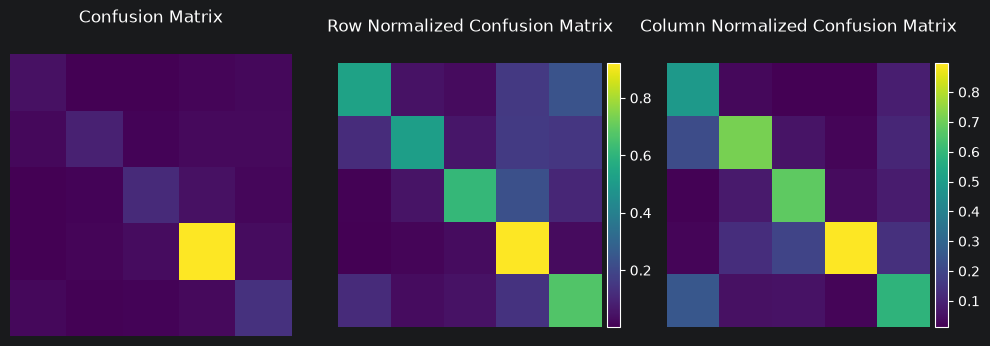

Confusion Matrix:
[[  58    5    3   17   26]
 [  26  113   13   35   32]
 [   2   12  146   54   24]
 [   3   20   42 1211   40]
 [  30    8   12   35  173]]

Row Normalized Confusion Matrix:
[[0.53211009 0.04587156 0.02752294 0.1559633  0.23853211]
 [0.11872146 0.51598174 0.05936073 0.15981735 0.14611872]
 [0.00840336 0.05042017 0.61344538 0.22689076 0.10084034]
 [0.00227964 0.01519757 0.03191489 0.92021277 0.03039514]
 [0.11627907 0.03100775 0.04651163 0.13565891 0.67054264]]

Column Normalized Confusion Matrix:
[[0.48739496 0.03164557 0.01388889 0.01257396 0.08813559]
 [0.21848739 0.71518987 0.06018519 0.02588757 0.10847458]
 [0.01680672 0.07594937 0.67592593 0.03994083 0.08135593]
 [0.02521008 0.12658228 0.19444444 0.89571006 0.13559322]
 [0.25210084 0.05063291 0.05555556 0.02588757 0.58644068]]


In [64]:
cm = confusion_matrix(all_labels, all_preds)
cm_row_normalized = confusion_matrix(all_labels, all_preds, normalize='true')
cm_column_normalized = confusion_matrix(all_labels, all_preds, normalize='pred')

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].matshow(cm, cmap='viridis')
ax[0].set_title('Confusion Matrix')
ax[0].axis('off')

im1 = ax[1].matshow(cm_row_normalized, cmap='viridis')
ax[1].set_title('Row Normalized Confusion Matrix')
ax[1].axis('off')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, ax=ax[1])

im2 = ax[2].matshow(cm_column_normalized, cmap='viridis')
ax[2].set_title('Column Normalized Confusion Matrix')
ax[2].axis('off')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax, ax=ax[2])

plt.tight_layout()
plt.show()

print(f'Confusion Matrix:\n{cm}\n\nRow Normalized Confusion Matrix:\n{cm_row_normalized}\n\nColumn Normalized Confusion Matrix:\n{cm_column_normalized}')

In [65]:
comparison = pd.DataFrame({
    "Split": ["Validation", "Test"],
    "Accuracy": [
        checkpoint['val_accuracy'],
        test_accuracy
    ],
    "Macro F1": [
        val_macro_f1,
        test_macro_f1
    ],
    "Weighted F1": [
        val_weighted_f1,
        test_weighted_f1
    ]
})

print(comparison)

        Split  Accuracy  Macro F1  Weighted F1
0  Validation  0.793925  0.649377     0.790326
1        Test  0.794860  0.656977     0.792476


In [66]:
# Test Prediction Table
checkpoint = torch.load('best_finetuned_resnet18.pt', weights_only=False)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

model.load_state_dict(checkpoint['model_state_dict'])

model = model.to(device)

test_dataset = CassavaDataset(test_df, image_dir, test_transform, return_path=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers = 4, persistent_workers=True, prefetch_factor=4)

all_labels = []
all_preds = []
all_probs = []
name_list = []
confidence_list = []

model.eval()

with torch.no_grad():
    for X, y, names in test_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        for name in names:
            name_list.append(name.split('/')[-1])

        logits = model(X)

        probs = torch.softmax(logits, dim=1)
        confidence, preds = probs.max(dim=1)

        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        confidence_list.extend(confidence.cpu().numpy())


In [67]:
test_predictions = pd.DataFrame(data={"image_id": name_list, "true_label": all_labels, "predicted_label": all_preds, 'confidence': confidence_list})

test_predictions['correct'] = (test_predictions['true_label'] == test_predictions['predicted_label'])
class_name_path = 'cassava-leaf-disease-classification/label_num_to_disease_map.json'

with open(class_name_path, 'r') as f:
    class_names = json.load(f)

class_names = {int(k): v for k, v in class_names.items()}
test_predictions['true_label_name'] = test_predictions['true_label'].map(class_names)
test_predictions['predicted_label_name'] = test_predictions['predicted_label'].map(class_names)

test_predictions.to_csv('Test_Predictions.csv', index=False)

In [69]:
test_predictions.head()

,image_id,true_label,predicted_label,confidence,correct,true_label_name,predicted_label_name
0,3993385288.jpg,3,3,0.540295,True,Cassava Mosaic Disease (CMD),Cassava Mosaic Disease (CMD)
1,3161381018.jpg,4,4,0.764140,True,Healthy,Healthy
2,3574527119.jpg,4,4,0.537393,True,Healthy,Healthy
3,254865851.jpg,3,3,0.831883,True,Cassava Mosaic Disease (CMD),Cassava Mosaic Disease (CMD)
4,483199386.jpg,3,3,0.954551,True,Cassava Mosaic Disease (CMD),Cassava Mosaic Disease (CMD)


In [102]:
errors = test_predictions.groupby('true_label_name').agg(
    total = ('true_label', 'count'),
    correct_vals = ('correct', (lambda x: (x == True).sum())),
    incorrect_vals = ('correct', (lambda x: (x==False).sum()))
)
errors['error_rate'] = errors['incorrect_vals'] / errors['total']

errors

,total,correct_vals,incorrect_vals,error_rate
true_label_name,,,,
Cassava Bacterial Blight (CBB),109,58,51,0.467890
Cassava Brown Streak Disease (CBSD),219,113,106,0.484018
Cassava Green Mottle (CGM),238,146,92,0.386555
Cassava Mosaic Disease (CMD),1316,1211,105,0.079787
Healthy,258,173,85,0.329457


In [127]:
error_matrix = cm_row_normalized.copy()
data = []
for i, class_name in enumerate(class_names.values()):
    for j, pred_name in enumerate(class_names.values()):
        if i != j:
            data.append({
                'class': class_name,
                'prediction': pred_name,
                'error': cm_row_normalized[i, j]
            })

class_confusion = pd.DataFrame(data=data)
class_confusion["count"] = [cm[i, j] for i in range(len(class_names)) for j in range(len(class_names)) if i != j]
class_confusion.sort_values("count", ascending=False, inplace=True, ignore_index=True)

class_confusion

,class,prediction,error,count
0,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),0.226891,54
1,Cassava Mosaic Disease (CMD),Cassava Green Mottle (CGM),0.031915,42
2,Cassava Mosaic Disease (CMD),Healthy,0.030395,40
3,Cassava Brown Streak Disease (CBSD),Cassava Mosaic Disease (CMD),0.159817,35
4,Healthy,Cassava Mosaic Disease (CMD),0.135659,35
5,Cassava Brown Streak Disease (CBSD),Healthy,0.146119,32
6,Healthy,Cassava Bacterial Blight (CBB),0.116279,30
7,Cassava Bacterial Blight (CBB),Healthy,0.238532,26
8,Cassava Brown Streak Disease (CBSD),Cassava Bacterial Blight (CBB),0.118721,26
9,Cassava Green Mottle (CGM),Healthy,0.100840,24


In [120]:
confidence_difference = test_predictions.groupby('true_label_name').agg(
    correct_confidence_mean = ('confidence', (lambda x: x[test_predictions.loc[x.index, 'correct']].mean())),
    correct_confidence_median = ('confidence', (lambda x: x[test_predictions.loc[x.index, 'correct']].median())),
    incorrect_confidence_mean = ('confidence', (lambda x: x[~test_predictions.loc[x.index, 'correct']].mean())),
    incorrect_confidence_median = ('confidence', (lambda x: x[~test_predictions.loc[x.index, 'correct']].median()))
)

In [121]:
confidence_difference

,correct_confidence_mean,correct_confidence_median,incorrect_confidence_mean,incorrect_confidence_median
true_label_name,,,,
Cassava Bacterial Blight (CBB),0.678189,0.673752,0.547995,0.536341
Cassava Brown Streak Disease (CBSD),0.747889,0.792179,0.570374,0.531958
Cassava Green Mottle (CGM),0.810920,0.884790,0.684329,0.688696
Cassava Mosaic Disease (CMD),0.903495,0.976468,0.593046,0.554169
Healthy,0.603892,0.565526,0.596676,0.577619


In [280]:
def create_diagnosis_set(df):
    if len(df) != 17:
        raise ValueError(
            f"DataFrame can only accept 17 images. "
            f"The parameter was given a DataFrame with {len(df)} images."
        )

    image_path = "cassava-leaf-disease-classification/train_images"
    simplified_class_names = {0: 'CBB', 1: 'CBSD', 2: 'CGM', 3: 'CMD', 4: 'Healthy'}

    diagnosis_transform = v2.Compose([
        v2.Resize(256),
        v2.CenterCrop(224),
        v2.ToImage()])

    fig, axs = plt.subplots(5, 4, figsize=(15, 10))

    for i in range(axs.shape[0]):
        for j in range(axs.shape[1]):
            idx = i * 4 + j

            if idx in [17, 18, 19]:
                axs[i, j].remove()
                continue

            current_image = f"{image_path}/{df.iloc[idx]['image_id']}"
            img = Image.open(current_image).convert("RGB")
            img = diagnosis_transform(img)
            axs[i, j].imshow(img.permute(1, 2, 0))
            axs[i, j].axis('off')
            title_string = (f"True: {simplified_class_names[df.iloc[idx]['true_label']]} |"
                            f" Pred: {simplified_class_names[df.iloc[idx]['predicted_label']]} |"
                            f" Conf: {df.iloc[idx]['confidence'] * 100:.3f}%")
            axs[i, j].set_title(title_string)


    plt.tight_layout()
    plt.show()

In [231]:
cgm_to_cmd = test_predictions[(test_predictions['true_label'] == 2) & (test_predictions['predicted_label'] == 3)].sort_values("confidence", ascending=False).iloc[0:2]
healthy_to_cbb = test_predictions[(test_predictions['true_label'] == 4) & (test_predictions['predicted_label'] == 0)].sort_values("confidence", ascending=False).iloc[0:2]
healthy_to_cbsd = test_predictions[(test_predictions['true_label'] == 4) & (test_predictions['predicted_label'] == 1)].sort_values("confidence", ascending=False).iloc[0:2]
healthy_to_cgm = test_predictions[(test_predictions['true_label'] == 4) & (test_predictions['predicted_label'] == 2)].sort_values("confidence", ascending=False).iloc[0:2]
healthy_to_cmd = test_predictions[(test_predictions['true_label'] == 4) & (test_predictions['predicted_label'] == 3)].sort_values("confidence", ascending=False).iloc[0:2]
cbsd_error = test_predictions[(test_predictions['true_label'] == 1) & (test_predictions['predicted_label'] != 1)].sort_values("confidence", ascending=False).iloc[0:2]
cbb_correct = test_predictions[(test_predictions['true_label'] == 0) & (test_predictions['correct'] == True)].sort_values("confidence", ascending=False).iloc[[0]]
cbsd_correct = test_predictions[(test_predictions['true_label'] == 1) & (test_predictions['correct'] == True)].sort_values("confidence", ascending=False).iloc[[0]]
cgm_correct = test_predictions[(test_predictions['true_label'] == 2) & (test_predictions['correct'] == True)].sort_values("confidence", ascending=False).iloc[[0]]
cmd_correct = test_predictions[(test_predictions['true_label'] == 3) & (test_predictions['correct'] == True)].sort_values("confidence", ascending=False).iloc[[0]]
healthy_correct = test_predictions[(test_predictions['true_label'] == 4) & (test_predictions['correct'] == True)].sort_values("confidence", ascending=False).iloc[[0]]

graphing_data = pd.concat([cgm_to_cmd, healthy_to_cbb, healthy_to_cbsd, healthy_to_cgm, healthy_to_cmd, cbsd_error, cbb_correct, cbsd_correct, cgm_correct, cmd_correct, healthy_correct], axis=0, ignore_index=True)

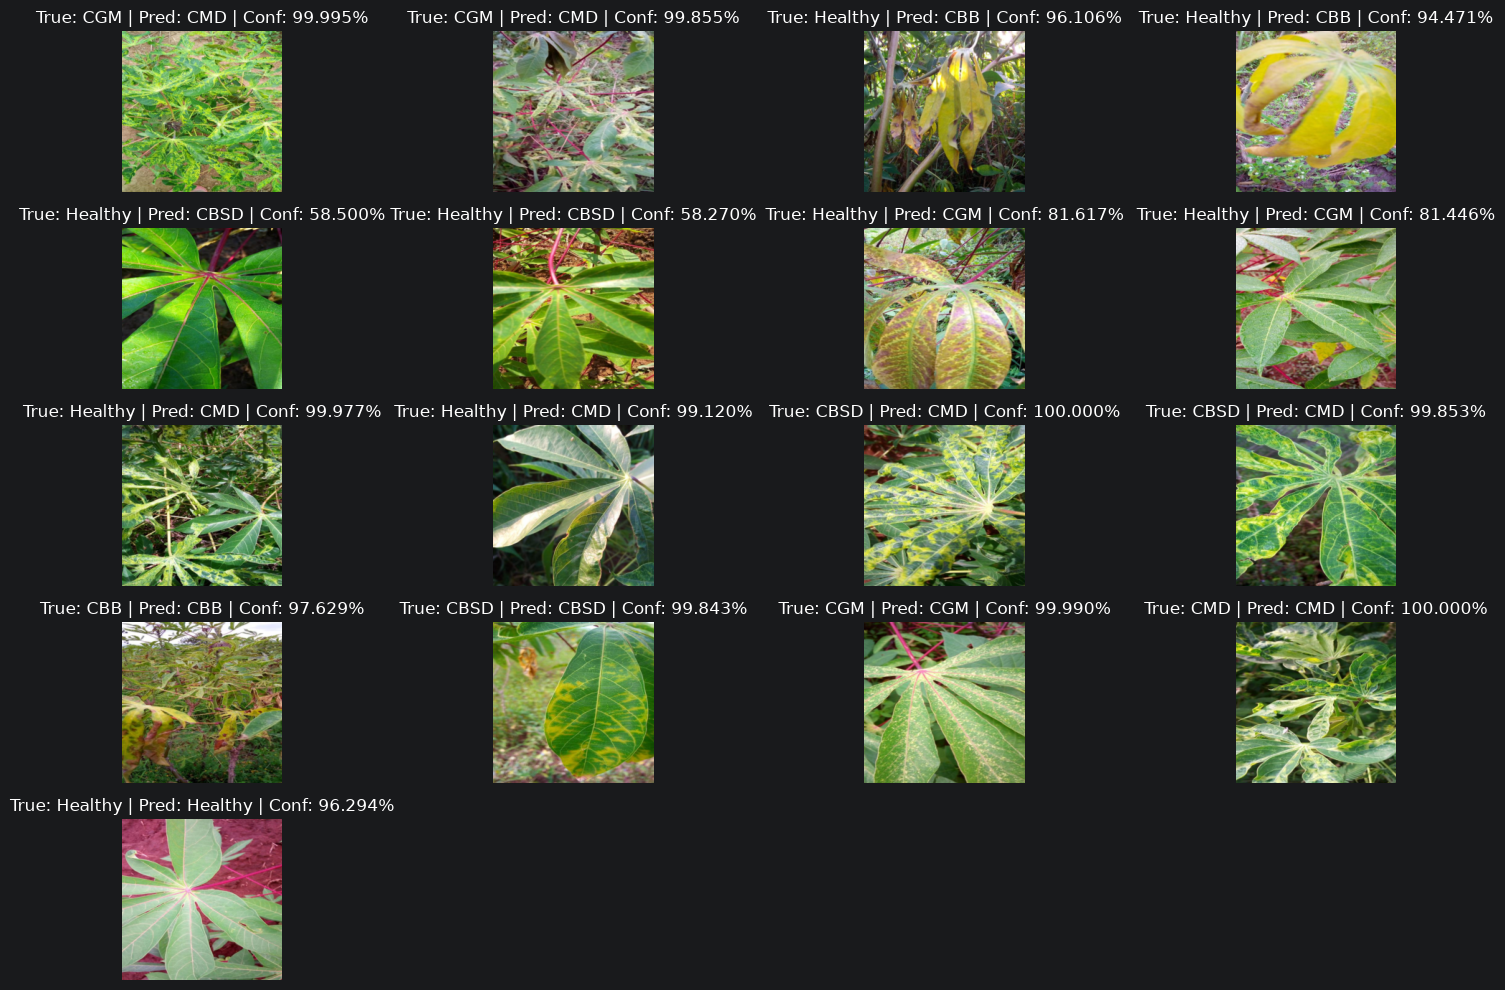

In [281]:
create_diagnosis_set(graphing_data)